# Seminarski rad iz Istraživanja podataka 2

U ovom seminarskom radu korišćen je javno dostupan skup podataka koji sadrži fiziološka merenja prikupljena sa ciljem automatskog prepoznavanja vrste aktivnosti čoveka. Podaci su prikupljeni od **40 ispitanika** starosti između 20 i 49 godina (12 žena i 28 muškaraca), pri čemu je svaki ispitanik bio izložen četiri različite vrste aktivnosti: **1-neutralnoj (odmor), 2-mentalnoj, 3-emocionalnoj i 4-fizičkoj aktivnosti**. Eksperiment je trajao približno 90 minuta po ispitaniku.

Tokom eksperimenta mereni su fiziološki signali **elektrokardiograma (ECG)**, **torakalne električne bioimpedance (TEB)** i **elektrodermalne aktivnosti (EDA)** pomoću nosivih senzora. Na osnovu ovih signala izračunat je veliki broj karakteristika (feature-a) u vremenskom i frekvencijskom domenu, uključujući različite statističke pokazatelje, parametre varijabilnosti srčanog ritma, energetske karakteristike, kao i druge srodne osobine. Na taj način dobijeno je ukupno **533 prediktora**.

## Preprocesiranje
Na samom početku, učitaćemo podatke iz .csv fajla gde se nalaze podaci o potrebnim prediktorima, a prediktore (labels) ćemo učitati preko funkcije .strip.


In [93]:
import pandas as pd

data = pd.read_csv("C:\\Users\\gala.posedi\\Downloads\\sensors-19-05524-s001\\sensors-19-05524-s001_new\\data.txt", header= None)
#u .txt fajlu labels poslednji red nam objasnjava kako se cita prediktor Activity, pa ga csv fajl ne moze prepoznati
#koristicemo funkciju .strip koji uklanja \n, tj novi red i druge razmake
#labels nije napisan u formatu standardne tabele, vec u formatu obicnog teksualnog fajla

#otvaramo fajl preko list comprehension
with open(r"C:\\Users\\gala.posedi\\Downloads\\sensors-19-05524-s001\\sensors-19-05524-s001_new\\labels.txt", "r") as f:
    labels = [line.strip() for line in f if line.strip()]

#preimenovacemo poslednju kolonu u Activity, bez objasnjenja kolone
labels[-1] = "Activity"
#data.columns = labels

Kako su autori zadržali ista imena kolona za različite stvari koje mere (negde je vršen EDA za ruke, negde ya podlaktice ali nigde nije naglašeno koji je koji), moraćemo promeniti naziv duplikatima, da bismo kasnije mogli vršiti dalju analizu.

In [94]:
from collections import defaultdict

counts = defaultdict(int)
labels_unique = []

for label in labels:
    counts[label] += 1
    
    if counts[label] == 1:
        labels_unique.append(label)
    else:
        labels_unique.append(label + "_" + str(counts[label]))

data.columns = labels_unique

print("Broj kolona:", data.shape[1])
print("Broj dupliranih naziva:", data.columns.duplicated().sum())

Broj kolona: 535
Broj dupliranih naziva: 0


In [95]:
print(data.columns)


Index(['Subject index (1-40)', 'ECG_original_mean', 'ECG_original_std',
       'ECG_original_trimmean25', 'ECG_original_median',
       'ECG_original_skewness', 'ECG_original_kurtosis', 'ECG_original_max',
       'ECG_original_min', 'ECG_original_prctile25',
       ...
       'EDA_Functionals_power_Filt2kurtosis_2',
       'EDA_Functionals_power_Filt2max_2', 'EDA_Functionals_power_Filt2min_2',
       'EDA_Functionals_power_Filt2prctile25_2',
       'EDA_Functionals_power_Filt2prctile75_2',
       'EDA_Functionals_power_Filt2geomean(abs)_2',
       'EDA_Functionals_power_Filt2harmmean_2',
       'EDA_Functionals_power_Filt2mad_2',
       'EDA_Functionals_power_Filt2baseline_2', 'Activity'],
      dtype='str', length=535)


Proveravamo dimenzije naše baze podataka, kao i broj redova koji pripadaju svakoj vrednosti target-a Activity, a kasnije ćemo pogledati tipovi svih atributa, kao i opšte informacije o bazi.

In [96]:
print("Dimenzije baze podataka: ", data.shape)
print("Broj redova za svaku vrednost target-a:")
print(data['Activity'].value_counts())

Dimenzije baze podataka:  (4480, 535)
Broj redova za svaku vrednost target-a:
Activity
1    1120
3    1120
2    1120
4    1120
Name: count, dtype: int64


In [97]:
print("Tipovi atributa:", data.dtypes)
print("\n")
print("Opste informacije o bazi:")
print(data.info())

Tipovi atributa: Subject index (1-40)                           int64
ECG_original_mean                            float64
ECG_original_std                             float64
ECG_original_trimmean25                      float64
ECG_original_median                          float64
                                              ...   
EDA_Functionals_power_Filt2geomean(abs)_2    float64
EDA_Functionals_power_Filt2harmmean_2        float64
EDA_Functionals_power_Filt2mad_2             float64
EDA_Functionals_power_Filt2baseline_2        float64
Activity                                       int64
Length: 535, dtype: object


Opste informacije o bazi:
<class 'pandas.DataFrame'>
RangeIndex: 4480 entries, 0 to 4479
Columns: 535 entries, Subject index (1-40) to Activity
dtypes: float64(520), int64(15)
memory usage: 18.3 MB
None


Analizom tipova podataka ustanovljeno je da su svi atributi numeričkog tipa (int64 ili float64). Ciljna promenljiva Activity već je predstavljena numerički,a kolonu "Subject Index" ćemo izbaciti iz baze.

Proveravamo i da li postoje nedostajuće vrednosti, kao i duplikati, i ukoliko ih ima, uklanjamo ih iz baze.

In [98]:
data.drop(columns = ["Subject index (1-40)"], inplace = True)
print("Broj nedostajućih vrednosti po kolonama:")
print(data.isna().sum())
print("Broj duplikata:")
print(data.duplicated().sum())
print("Broj duplikata po kolonama:")
print(data.columns.duplicated().sum())

Broj nedostajućih vrednosti po kolonama:
ECG_original_mean                            0
ECG_original_std                             0
ECG_original_trimmean25                      0
ECG_original_median                          0
ECG_original_skewness                        0
                                            ..
EDA_Functionals_power_Filt2geomean(abs)_2    0
EDA_Functionals_power_Filt2harmmean_2        0
EDA_Functionals_power_Filt2mad_2             0
EDA_Functionals_power_Filt2baseline_2        0
Activity                                     0
Length: 534, dtype: int64
Broj duplikata:
0
Broj duplikata po kolonama:
0


### Redukcija početnog skupa podataka
S obzirom na to da skup podataka sadrži veliki broj prediktora dobijenih iz istih fizioloških signala, očekuje se postojanje značajne međusobne korelacije između njih. Zbog toga ćemo izvršiti određenu redukciju baze, najpre primenjenom Pearsonov-e korelacije a kasnije i pomoću redukcije dimnezionalnosti, koristeći PCA metod.


In [99]:
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np

X = data.drop(columns=["Activity"])
y = data["Activity"]

corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.8)]

X_pearson = X.drop(columns=to_drop)

pearson_data = X_pearson.copy()
pearson_data["Activity"] = y

print("Broj atributa pre Pearson redukcije:", X.shape[1])
print("Broj izbačenih atributa:", len(to_drop))
print("Broj atributa posle Pearson redukcije:", X_pearson.shape[1])

print(pearson_data.head())

Broj atributa pre Pearson redukcije: 533
Broj izbačenih atributa: 430
Broj atributa posle Pearson redukcije: 103
   ECG_original_mean  ECG_original_std  ECG_original_skewness  \
0          -0.004125          0.254095              -0.538509   
1           0.031029          0.193761               0.781415   
2           0.015678          0.182336               0.881194   
3           0.014525          0.176636               1.024900   
4           0.010349          0.179248               0.935697   

   ECG_original_kurtosis  ECG_original_prctile25  ECG_original_harmmean  \
0                5.95534                -0.10937              -0.065212   
1                5.18794                -0.08737              -0.057924   
2                5.66530                -0.08037              -0.042190   
3                6.10968                -0.08037              -0.044888   
4                5.83902                -0.08337              -0.041310   

   ECG_original_baseline  ECG_RR_window_mean 

PCA metod za redukovanje dimenzionalnosti i implementacija t-SNE metode za 2D vizuelizaciju podataka: 

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)


In [101]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_standardized)
print("Broj komponenti posle PCA:", pca.n_components_)
print("Udeo svake komponente:", pca.explained_variance_ratio_)
print("Procenat disperzije objašnjen sa PCA:", pca.explained_variance_ratio_.sum())

Broj komponenti posle PCA: 61
Udeo svake komponente: [0.18457093 0.11944473 0.11201854 0.10262701 0.05041005 0.04335714
 0.02562293 0.02340832 0.02257984 0.01894359 0.01686517 0.01384434
 0.01336002 0.01265527 0.01213856 0.01065933 0.01049484 0.00941335
 0.00877775 0.00816402 0.00758126 0.00622047 0.00613049 0.00604647
 0.00559769 0.00545748 0.00484377 0.00454554 0.0044642  0.00434581
 0.00425419 0.00389667 0.00373631 0.0036342  0.00341261 0.00332661
 0.0031459  0.00300596 0.00279069 0.00257052 0.0025343  0.00249466
 0.00240817 0.00230266 0.00230096 0.00218483 0.00215148 0.0021329
 0.00202237 0.0019856  0.00194357 0.00193    0.00189689 0.00187195
 0.00184624 0.00182563 0.00180758 0.00179829 0.00175173 0.0017036
 0.00166371]
Procenat disperzije objašnjen sa PCA: 0.9509196965411426


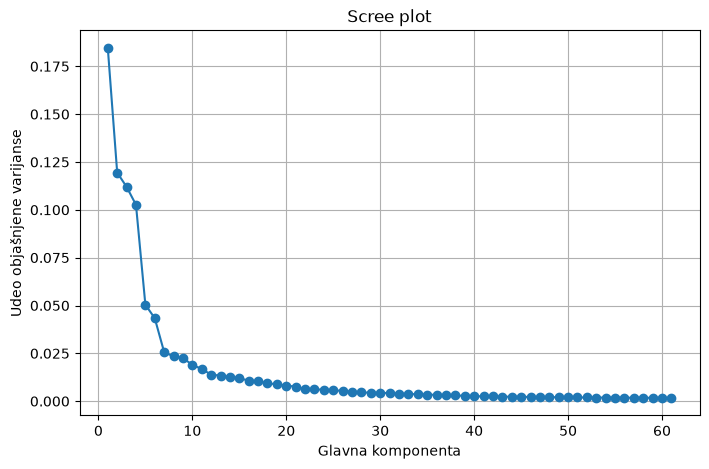

In [102]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')

plt.xlabel("Glavna komponenta")
plt.ylabel("Udeo objašnjene varijanse")
plt.title("Scree plot")
plt.grid(True)

plt.show()

Možemo i vizuelno pokazati da nam je 61 prediktor sasvim dovoljan, jer objašnjavaju dovoljni udeo disperzije.

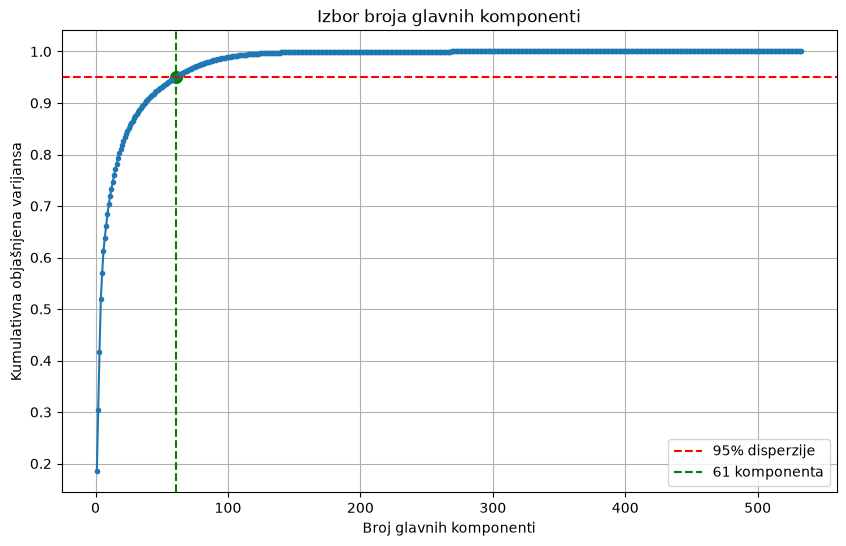

In [103]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_all = PCA()
pca_all.fit(X_standardized)

#kumulativna disperzija
cum_var = np.cumsum(pca_all.explained_variance_ratio_)

n95 = np.argmax(cum_var >= 0.95) + 1

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', markersize=3)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% disperzije')
plt.axvline(x=n95, color='green', linestyle='--',label=f'{n95} komponenta')

plt.scatter(n95, cum_var[n95-1], color='green', s=70)

plt.xlabel("Broj glavnih komponenti")
plt.ylabel("Kumulativna objašnjena varijansa")
plt.title("Izbor broja glavnih komponenti")
plt.grid(True)
plt.legend()

plt.show()



### Vizuelizacija prethodnih metoda redukcija dimenzionalnosti korišćenjem t-SNE metode


In [104]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

scaler_pearson = StandardScaler()
X_pearson_standardized = scaler_pearson.fit_transform(X_pearson)

tsne_pearson = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)

X_tsne_pearson = tsne_pearson.fit_transform(X_pearson_standardized)

In [105]:
tsne_pca = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_tsne_pca = tsne_pca.fit_transform(X_pca)

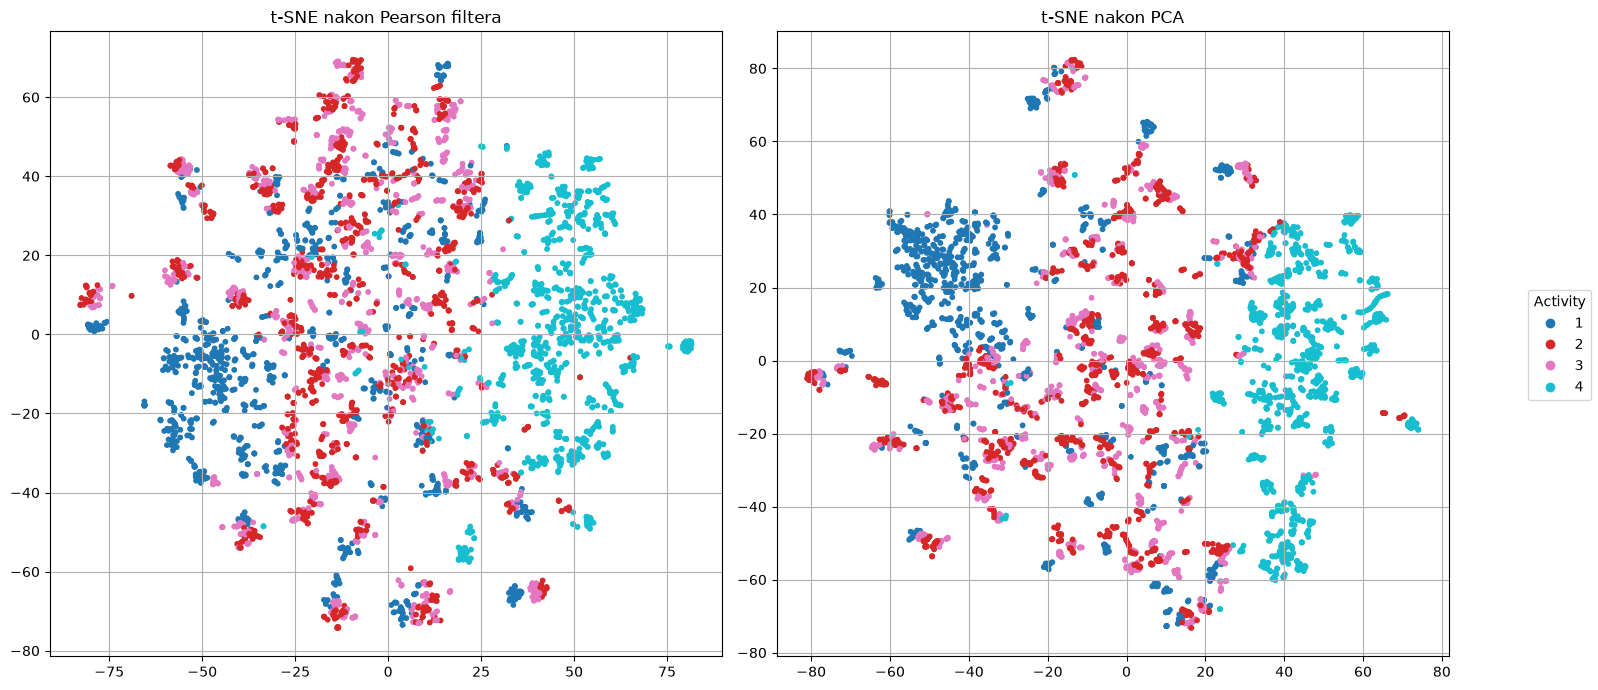

In [106]:
from operator import le


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

scatter1 = axes[0].scatter(X_tsne_pearson[:, 0], X_tsne_pearson[:, 1], c = y, cmap="tab10", s=10)

axes[0].set_title("t-SNE nakon Pearson filtera")
axes[0].grid(True)

scatter2 = axes[1].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c = y, cmap="tab10", s=10)

axes[1].set_title("t-SNE nakon PCA")
axes[1].grid(True)

fig.legend(handles=scatter1.legend_elements()[0], labels = range(1,5),title="Activity",loc="center right")
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

Na osnovu dobijenih grafika može se uočiti da obe metode omogućavaju izdvajanje četvrte klase, dok se druga i treća klasa značajno preklapaju. Projekcija nakon PCA pokazuje nešto kompaktnije klastere, posebno za prvu klasu, što ukazuje da PCA uspešnije zadržava strukturu podataka nakon redukcije dimenzionalnosti.

## Klasifikacija

Za klasifikaciju target-a odabrano je pet algoritama različite složenosti i principa rada. Prva je logistička regresija, pa SVM kao metoda pogodna za nelinearne granice odlučivanja, pa Random Forest kao predstavnik bagging ensemble metoda i na kraju su implementirane AdaBoost i XGBoost koje predstavljaju dve boosting metode. 

### Logistička regresija
Kako postoje četiri vrste klase target promenljive Activity, koristićemo polinomijalnu logističku regresiju.

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score)

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_standardized,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train_all.shape, X_test_all.shape)
print(y_train.shape, y_test.shape)

(3136, 533) (1344, 533)
(3136,) (1344,)


In [108]:
model = LogisticRegression(solver="lbfgs", max_iter = 1000, random_state = 42)
model.fit(X_train_all, y_train)

y_pred = model.predict(X_test_all)

matrica_konfuzije_all = confusion_matrix(y_test, y_pred)


In [109]:
#metrike evaluacije

accuracy_all = accuracy_score(y_test, y_pred)
precision_all = precision_score(y_test, y_pred, average="weighted")
recall_all = recall_score(y_test, y_pred, average="weighted")
f1_all = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy_all:.4f}")
print(f"Precision: {precision_all:.4f}")
print(f"Recall   : {recall_all:.4f}")
print(f"F1-score : {f1_all:.4f}")

Accuracy : 0.8728
Precision: 0.8729
Recall   : 0.8728
F1-score : 0.8728


Sada ćemo implementirati logističku regresiju nad određenim skupom podataka koji smo dobili PCA redukcijom.

In [110]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.3,      
    train_size=0.7,     
    random_state=42,    
    stratify=y         
)

model = LogisticRegression(solver="lbfgs", max_iter = 1000, random_state = 42)
model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)

matrica_konfuzije_pca = confusion_matrix(y_test, y_pred)

In [111]:
#metrike evaluacije

accuracy_pca = accuracy_score(y_test, y_pred)
precision_pca = precision_score(y_test, y_pred, average="weighted")
recall_pca = recall_score(y_test, y_pred, average="weighted")
f1_pca = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall   : {recall_pca:.4f}")
print(f"F1-score : {f1_pca:.4f}")

Accuracy : 0.8132
Precision: 0.8154
Recall   : 0.8132
F1-score : 0.8142


Sada ćemo uporediti matrice konfuzije ovih dvaju skupa prediktora.

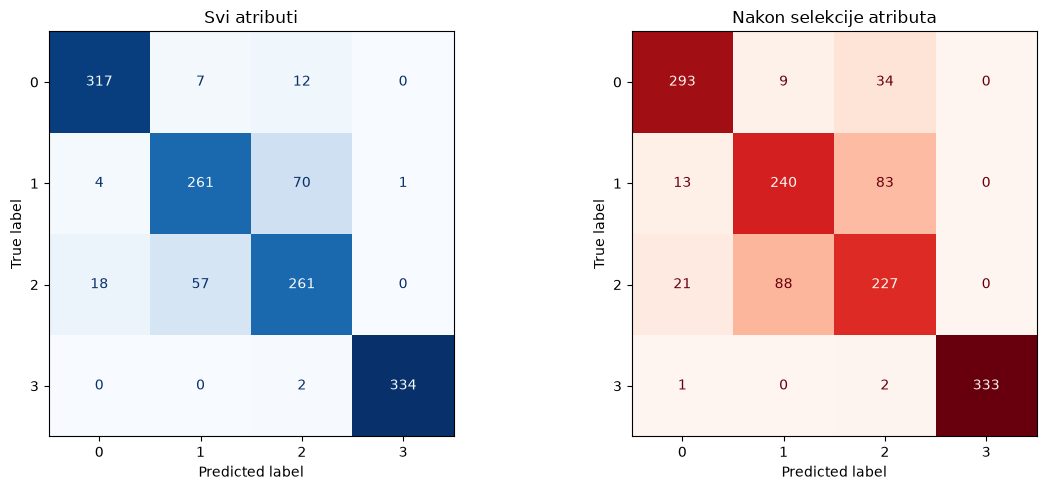

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=matrica_konfuzije_all).plot(ax=axes[0],cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Svi atributi") 

ConfusionMatrixDisplay(confusion_matrix=matrica_konfuzije_pca).plot(ax=axes[1],cmap="Reds",values_format="d",colorbar=False)
axes[1].set_title("Nakon selekcije atributa")

plt.tight_layout()
plt.show()

Nakon redukcije broja prediktora povećava se broj pogrešno klasifikovanih uzoraka, naročito između klasa 2 i 3, što ukazuje da su pojedini odbačeni atributi sadržali diskriminativne informacije važne za razlikovanje ovih klasa. Iako selekcija atributa doprinosi smanjenju dimenzionalnosti i može povećati jednostavnost modela, u ovom slučaju je dovela do blagog gubitka informacija.

Ovakav rezultat je u skladu sa prethodnom analizom podataka, koja je pokazala da su mnogi prediktori međusobno visoko korelisani. Zbog toga je uklanjanje redundantnih atributa doprinelo formiranju jednostavnijeg i robusnijeg modela, uz zanemarljiv pad tačnosti. Takav model je manje podložan overfitting-u i može pružiti pouzdanije rezultate prilikom primene na novim podacima.

### SVM model
Sada ćemo klasifikovati target promenljivu koristeći SVM metod, da bismo videli da li nelinearni metod bolje predviđa target promenljivu od linearnog.

In [113]:

from sklearn.svm import SVC

svm_model_all = SVC(kernel="rbf",C=1.0,gamma="scale",random_state=42)

svm_model_all.fit(X_train_all, y_train)
y_pred_svm_all = svm_model_all.predict(X_test_all)

matrica_konfuzije_svm_all = confusion_matrix(y_test, y_pred_svm_all)

In [114]:
#metrike evaluacije

accuracy_all = accuracy_score(y_test, y_pred)
precision_all = precision_score(y_test, y_pred, average="weighted")
recall_all = recall_score(y_test, y_pred, average="weighted")
f1_all = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy_all:.4f}")
print(f"Precision: {precision_all:.4f}")
print(f"Recall   : {recall_all:.4f}")
print(f"F1-score : {f1_all:.4f}")

Accuracy : 0.8132
Precision: 0.8154
Recall   : 0.8132
F1-score : 0.8142


Vidimo da je implementacijom SVM modela nad celim skupom podataka performanse malo opale, sve metrike imaju vrednost od približno 0.81. 

Sada ćemo implementirati model nad PCA atributima.

In [115]:
svm_model_pca = SVC(kernel="rbf",C=1.0,gamma="scale",random_state=42)

svm_model_pca.fit(X_train_pca, y_train)
y_pred_svm_pca = svm_model_pca.predict(X_test_pca)

matrica_konfuzije_svm_pca = confusion_matrix(y_test, y_pred_svm_pca)

In [116]:
#metrike evaluacije

accuracy_pca = accuracy_score(y_test, y_pred_svm_pca)
precision_pca = precision_score(y_test, y_pred_svm_pca, average="weighted")
recall_pca = recall_score(y_test, y_pred_svm_pca, average="weighted")
f1_pca = f1_score(y_test, y_pred_svm_pca, average="weighted")

print(f"Accuracy : {accuracy_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall   : {recall_pca:.4f}")
print(f"F1-score : {f1_pca:.4f}")

Accuracy : 0.8311
Precision: 0.8372
Recall   : 0.8311
F1-score : 0.8325




Matrice konfuzije za oba skupa podataka:

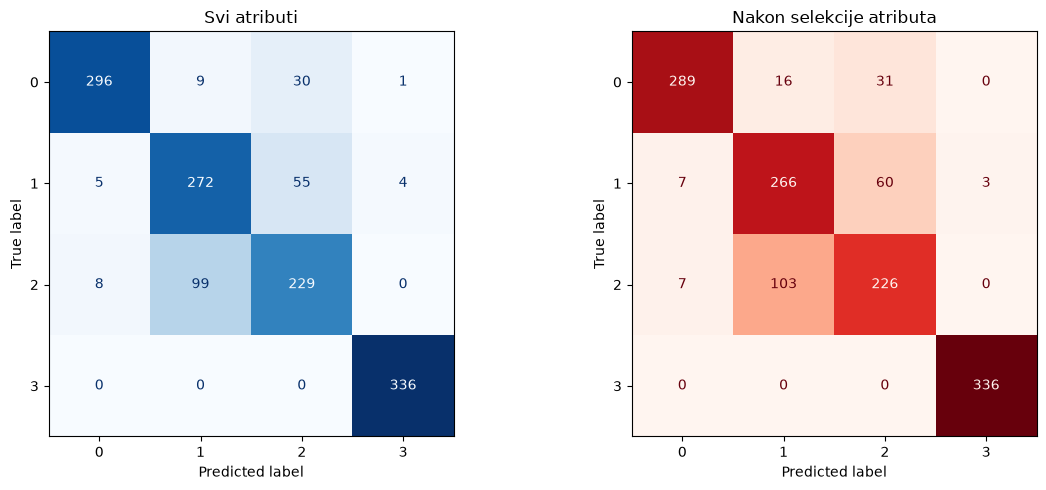

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=matrica_konfuzije_svm_all).plot(ax=axes[0],cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Svi atributi") 

ConfusionMatrixDisplay(confusion_matrix=matrica_konfuzije_svm_pca).plot(ax=axes[1],cmap="Reds",values_format="d",colorbar=False)
axes[1].set_title("Nakon selekcije atributa")

plt.tight_layout()
plt.show()

### Random forest model
Random Forest je ansambl algoritam koji klasifikaciju vrši kombinovanjem rezultata velikog broja stabala odlučivanja. Ovakav pristup povećava tačnost modela i smanjuje rizik od preprilagođavanja.

In [118]:
from sklearn.ensemble import RandomForestClassifier

rf_model_all = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model_all.fit(X_train_all, y_train)

y_pred_all = rf_model_all.predict(X_test_all)

print(f"Accuracy : {accuracy_score(y_test, y_pred_all):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_all, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_all, average='weighted'):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_all, average='weighted'):.4f}")

matrica_konfuzije_rf_all = confusion_matrix(y_test, y_pred_all)

Accuracy : 0.9583
Precision: 0.9593
Recall   : 0.9583
F1-score : 0.9585


In [119]:

rf_model_pca = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model_pca.fit(X_train_pca, y_train)

y_pred_pca = rf_model_pca.predict(X_test_pca)

print(f"Accuracy : {accuracy_score(y_test, y_pred_pca):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_pca, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_pca, average='weighted'):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_pca, average='weighted'):.4f}")

matrica_konfuzije_rf_pca = confusion_matrix(y_test, y_pred_pca)

Accuracy : 0.8720
Precision: 0.8745
Recall   : 0.8720
F1-score : 0.8723


Za razliku od logističke regresije i SVM modela, kod Random Forest algoritma primena PCA dovela je do uočljivijeg smanjenja performansi. Ovakav rezultat ukazuje da Random Forest efikasnije iskorišćava informacije sadržane u originalnim atributima.

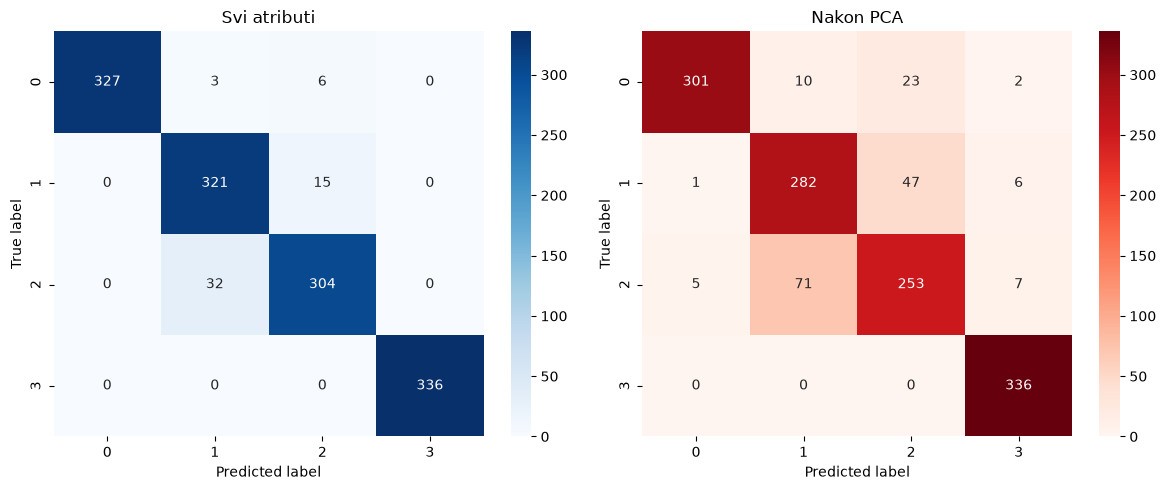

In [120]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(matrica_konfuzije_rf_all,annot=True,fmt="d",cmap="Blues",ax=axes[0])

axes[0].set_title("Svi atributi")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(matrica_konfuzije_rf_pca,annot=True,fmt="d",cmap="Reds",ax=axes[1])

axes[1].set_title("Nakon PCA")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.show()

### AdaBoost algoritam

In [121]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_tree = DecisionTreeClassifier(max_depth=1,random_state=42)

ada_model_all = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# treniranje modela
ada_model_all.fit(X_train_all, y_train)

# predikcija
y_pred_ada = ada_model_all.predict(X_test_all)

# evaluacija
print(f"Accuracy : {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ada, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_ada, average='weighted'):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_ada, average='weighted'):.4f}")



Accuracy : 0.7440
Precision: 0.7608
Recall   : 0.7440
F1-score : 0.7502


In [122]:
ada_model_pca = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_model_pca.fit(X_train_pca, y_train)

y_pred_ada_pca = ada_model_pca.predict(X_test_pca)

print(f"Accuracy : {accuracy_score(y_test, y_pred_ada_pca):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ada_pca, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_ada_pca, average='weighted'):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_ada_pca, average='weighted'):.4f}")


Accuracy : 0.7135
Precision: 0.7167
Recall   : 0.7135
F1-score : 0.7139


Vidimo da su ovde performanse značajno opale, za prvi skup su sve metrike oko 0.75, dok su za PCA skup vrednosti oko 0.72, što govori o tome da ovaj metod ne procenjuje dobro klase. Jedan od razloga može biti to da AdaBoost gradi ansambl velikog broja plitkih stabala koja prvenstveno ispravljaju greške prethodnih modela, ali pri tome teže hvataju složenije nelinearne odnose. Zato ćemo implementirati i XGBoost algoritam.

### XGBoost algoritam

In [123]:
from xgboost import XGBClassifier

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model_all = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model_all.fit(X_train_all, y_train_xgb)

y_pred_xgb = xgb_model_all.predict(X_test_all)

accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
precision = precision_score(y_test_xgb, y_pred_xgb, average="weighted")
recall = recall_score(y_test_xgb, y_pred_xgb, average="weighted")
f1 = f1_score(y_test_xgb, y_pred_xgb, average="weighted")

print("XGBoost rezultati:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


matrica_konfuzija_xgb_all = confusion_matrix(y_test_xgb, y_pred_xgb)

XGBoost rezultati:
Accuracy : 0.9888
Precision: 0.9889
Recall   : 0.9888
F1-score : 0.9888


In [124]:

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model_pca = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model_pca.fit(X_train_pca, y_train_xgb)

y_pred_xgb = xgb_model_pca.predict(X_test_pca)

accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
precision = precision_score(y_test_xgb, y_pred_xgb, average="weighted")
recall = recall_score(y_test_xgb, y_pred_xgb, average="weighted")
f1 = f1_score(y_test_xgb, y_pred_xgb, average="weighted")

print("XGBoost rezultati:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


matrica_konfuzija_xgb_pca = confusion_matrix(y_test_xgb, y_pred_xgb)

XGBoost rezultati:
Accuracy : 0.8839
Precision: 0.8853
Recall   : 0.8839
F1-score : 0.8843


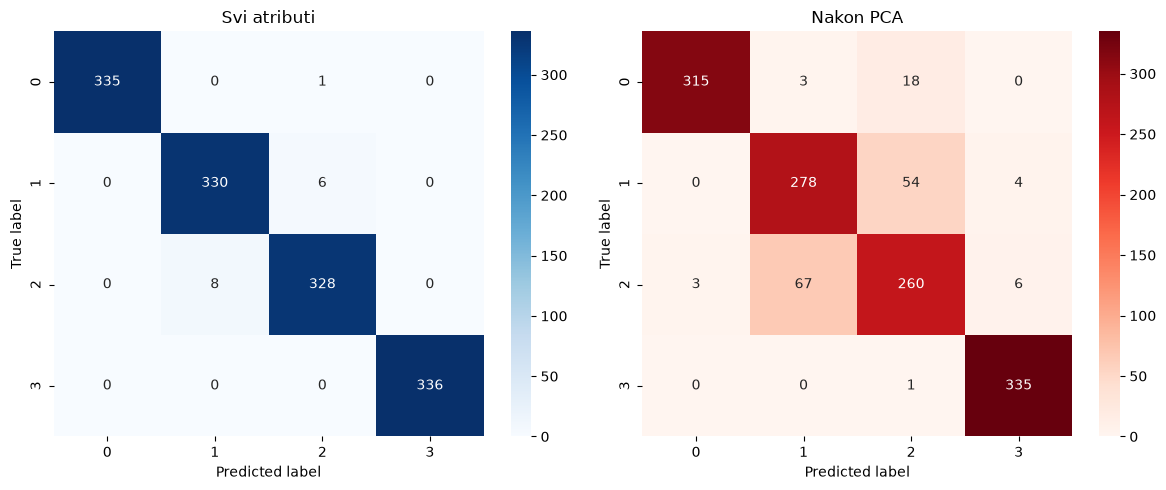

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(matrica_konfuzija_xgb_all,annot=True,fmt="d",cmap="Blues",ax=axes[0])

axes[0].set_title("Svi atributi")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(matrica_konfuzija_xgb_pca,annot=True,fmt="d",cmap="Reds",ax=axes[1])

axes[1].set_title("Nakon PCA")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.show()

Rezultati pokazuju da je XGBoost ostvario veoma visoke performanse na skupu sa svim prediktorima. Nakon primene PCA uočava se očekivani pad performansi, ali model i dalje zadržava visok nivo tačnosti, što ukazuje da je najveći deo informacija relevantnih za klasifikaciju sačuvan i nakon redukcije dimenzionalnosti.

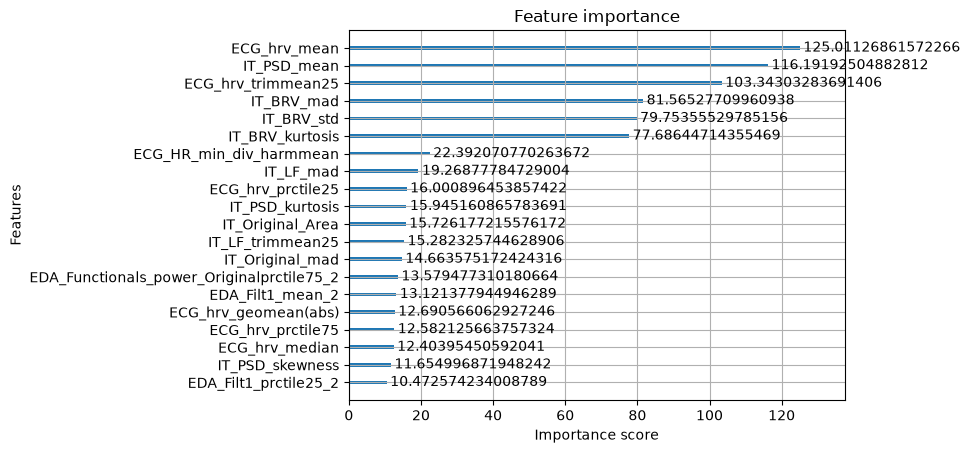

In [126]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

#grafik značajnosti prediktora
booster = xgb_model_all.get_booster()
booster.feature_names = list(X.columns)
plot_importance(
    booster,
    importance_type="gain",
    max_num_features=20
)
plt.show()

Grafik pokazuje da XGBoost ne koristi sve atribute podjednako, već najveći doprinos klasifikaciji imaju određene karakteristike, dok je uticaj ostalih znatno manji. To ukazuje da model najveći deo odluka zasniva na ograničenom broju najinformativnijih karakteristika, koje prema kriterijumu gain ostvaruju najveće smanjenje greške prilikom izgradnje stabala odlučivanja.

## Klasterovanje

Za klasterovanje target promenljive koristićemo pet algoritama: KMeans+++, DBSCAN, HDBSCAN, Hierarchical KMeans i Optics. KMeans++ i Hierarchical KMeans zahtevaju unapred zadati broj klastera, kako target promenljiva ima 4 različite grupe, toliko ćemo klastera i zadati unapred.
Najpre ćemo raditi nad celim skupom podataka, a onda nad PCA skupom i uporediti rezultate.

In [127]:
from sklearn.cluster import KMeans, DBSCAN, OPTICS, AgglomerativeClustering
import hdbscan
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score)


clusterers = {
    "kmeans_pp": KMeans(n_clusters=4, init="k-means++", random_state=42),
    "hierarchical_kmeans": AgglomerativeClustering(n_clusters=4, linkage="ward"),
    "dbscan": DBSCAN(eps=0.1, min_samples=30),
    "hdbscan": hdbscan.HDBSCAN(min_cluster_size=50),
    "optics": OPTICS(min_samples=10),
}


results = []
cluster_labels = {}

for name, model in clusterers.items():
    labels = model.fit_predict(X_standardized)
    cluster_labels[name] = labels

    if len(set(labels)) > 1:
        sil = silhouette_score(X_standardized, labels, sample_size=500, random_state=42)
        ch = calinski_harabasz_score(X_standardized, labels)
        db = davies_bouldin_score(X_standardized, labels)
    else:
        sil, ch, db = None, None, None

    results.append({
        "Algorithm": name,
        "Clusters": len(set(labels)),
        "Silhouette": sil,
        "Calinski-Harabasz": ch,
        "Davies-Bouldin": db
    })

results = pd.DataFrame(results)
results.sort_values("Silhouette", ascending=False)

,Algorithm,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,kmeans_pp,4,0.298563,633.276740,1.397482
1,hierarchical_kmeans,4,0.260801,563.169173,1.628007
3,hdbscan,3,0.055490,206.018248,2.593387
4,optics,59,-0.293624,14.896902,1.783912
2,dbscan,1,NaN,NaN,NaN


Na osnovu svih evaluacionih metrika može se zaključiti da je KMeans++ ostvario najbolje performanse, jer je dao najveći Silhouette i Calinski-Harabasz indeks, kao i najmanji Davies-Bouldin indeks. Hierarchical KMeans je pokazao vrlo slične rezultate, što potvrđuje da su centroidne metode najpogodnije za ovaj skup podataka. Nasuprot tome, algoritmi zasnovani na gustini (DBSCAN, HDBSCAN i OPTICS) nisu bili uspešni, što se može objasniti velikom dimenzionalnošću i karakteristikama skupa podataka, zbog kojih gustina uzoraka nije dovoljno izražena za efikasno formiranje klastera.

Vizuelizacija klasterizacije koristeći UMAP algoritam:

c:\Users\gala.posedi\Desktop\fakultet\IP2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


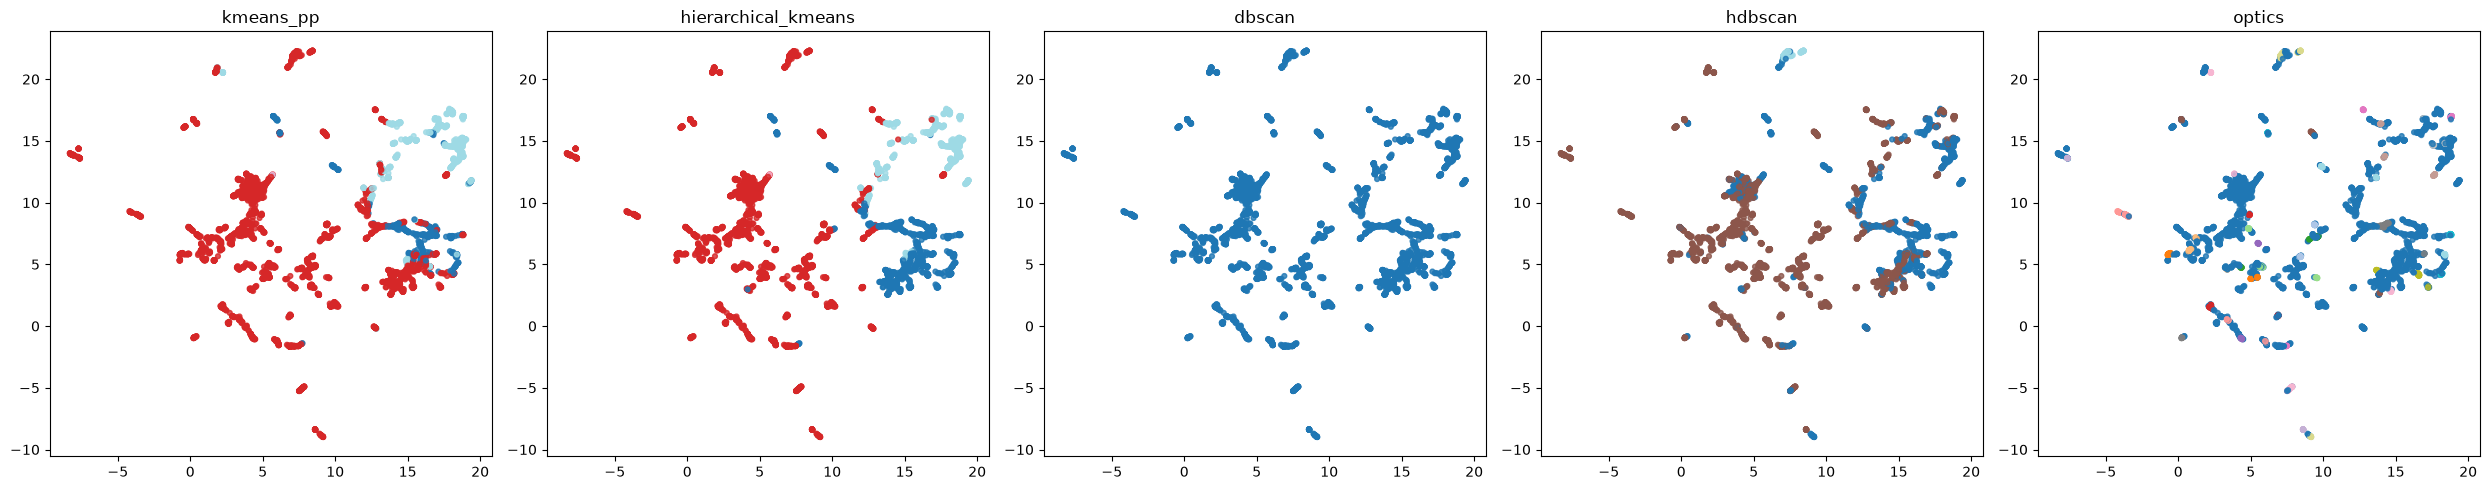

In [128]:
from umap import UMAP

umap_model = UMAP(n_components=2,n_neighbors=15,min_dist=0.1,random_state=42)

X_umap = umap_model.fit_transform(X_standardized)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (name, labels) in zip(axes, cluster_labels.items()):
    ax.scatter(X_umap[:, 0],X_umap[:, 1],c=labels,cmap="tab20",s=12,alpha=0.8)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [129]:
clusterers = {
    "kmeans_pp": KMeans(n_clusters=4, init="k-means++", random_state=42),
    "hierarchical_kmeans": AgglomerativeClustering(n_clusters=4, linkage="ward"),
    "dbscan": DBSCAN(eps=0.1, min_samples=30),
    "hdbscan": hdbscan.HDBSCAN(min_cluster_size=50),
    "optics": OPTICS(min_samples=10),
}


results = []
cluster_labels = {}

for name, model in clusterers.items():
    labels = model.fit_predict(X_pca)
    cluster_labels[name] = labels

    if len(set(labels)) > 1:
        sil = silhouette_score(X_pca, labels, sample_size=500, random_state=42)
        ch = calinski_harabasz_score(X_pca, labels)
        db = davies_bouldin_score(X_pca, labels)
    else:
        sil, ch, db = None, None, None

    results.append({
        "Algorithm": name,
        "Clusters": len(set(labels)),
        "Silhouette": sil,
        "Calinski-Harabasz": ch,
        "Davies-Bouldin": db
    })

results = pd.DataFrame(results)
results.sort_values("Silhouette", ascending=False)

,Algorithm,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,kmeans_pp,4,0.331536,624.926415,1.204698
1,hierarchical_kmeans,4,0.280562,594.264311,1.558878
3,hdbscan,3,0.076168,228.281320,2.453354
4,optics,67,-0.278109,14.484230,1.740895
2,dbscan,1,NaN,NaN,NaN


Sada ćemo odraditi istu klasterizaciju samo nad PCA izabranim prediktorima.

c:\Users\gala.posedi\Desktop\fakultet\IP2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


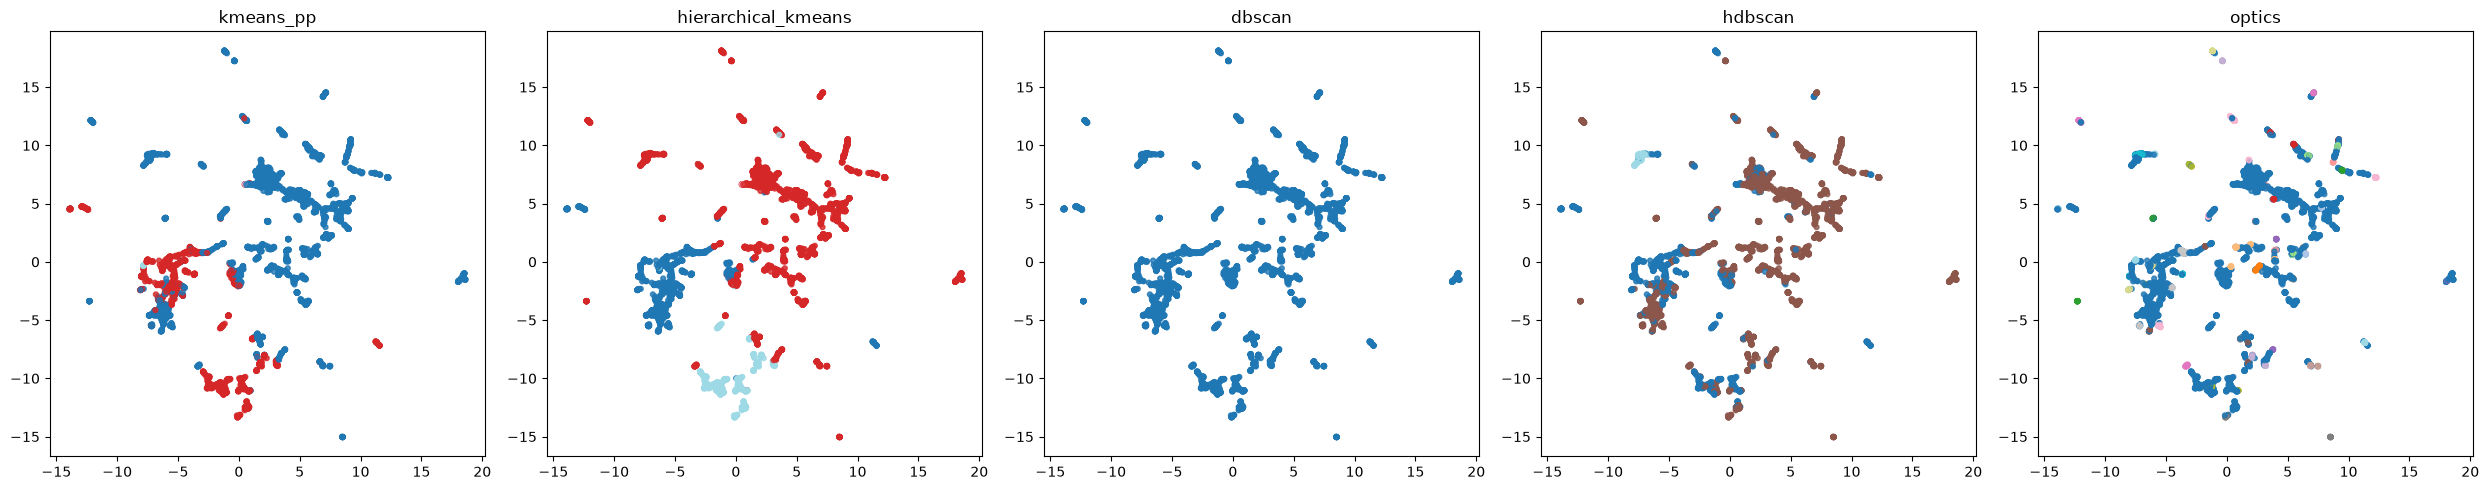

In [130]:
umap_model = UMAP(n_components=2,n_neighbors=15,min_dist=0.1,random_state=42)

X_umap_pca = umap_model.fit_transform(X_pca)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (name, labels) in zip(axes, cluster_labels.items()):
    ax.scatter(X_umap_pca[:, 0],X_umap_pca[:, 1],c=labels,cmap="tab20",s=12,alpha=0.8)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Pravila pridruživanja

Implementiraćemo dve metode - Apriori i FP-Growth algoritam nad PCA izabranim prediktorima, zbog velike međusobne korelisanosti.

Nakon generisanja pravila pridruživanja izvršićemo i filtriranje na osnovu vrednosti support, confidence i lift. Na taj način izdvojiće se samo pravila koja se javljaju dovoljno često, imaju visoku pouzdanost i predstavljaju statistički značajnu povezanost između stavki, dok su slaba i slučajna pravila odbačena radi jednostavnosti i interpretabilnosti rezultata.

In [131]:
from mlxtend.frequent_patterns import apriori, association_rules


#Apriori algoritam

X_top = pd.DataFrame(X_pca,columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])


#diskretizacija numeričkih promenljivih
def discretize_column(col):
    try:
        bins = pd.qcut(col, q=3, labels=False, duplicates="drop")
        return bins.map({0: "low", 1: "medium", 2: "high"})
    except:
        return "constant"

X_disc = X_top.apply(discretize_column)

X_disc["Activity"] = "Activity_" + y.astype(str)

transactions = pd.get_dummies(X_disc.astype(str))

frequent_itemsets = apriori(transactions,min_support=0.05,use_colnames=True,max_len=2)

rules = association_rules(frequent_itemsets,metric="confidence",min_threshold=0.70)

rules_f = rules[
    (rules["support"] >= 0.10) &
    (rules["confidence"] >= 0.70) &
    (rules["lift"] >= 1.50)
].sort_values(by="lift", ascending=False)

print("Unfiltered rules:", len(rules))
print("Filtered rules:", len(rules_f))

rules_f[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

Unfiltered rules: 6
Filtered rules: 6


,antecedents,consequents,support,confidence,lift
3,frozenset({Activity_Activity_4}),frozenset({PC5_low}),0.221429,0.885714,2.655957
4,frozenset({Activity_Activity_4}),frozenset({PC6_high}),0.201563,0.806250,2.419290
0,frozenset({Activity_Activity_4}),frozenset({PC1_high}),0.199330,0.797321,2.392498
1,frozenset({PC6_high}),frozenset({PC5_low}),0.254018,0.762224,2.285651
2,frozenset({PC5_low}),frozenset({PC6_high}),0.254018,0.761714,2.285651
5,frozenset({Activity_Activity_1}),frozenset({PC8_low}),0.183036,0.732143,2.195448


In [132]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# FP-Growth algoritam
frequent_itemsets_fp = fpgrowth(transactions,min_support=0.10,use_colnames=True,max_len=2)

rules_fp = association_rules(frequent_itemsets_fp,metric="confidence",min_threshold=0.70)


rules_fp_f = rules_fp[
    (rules_fp["support"] >= 0.10) &
    (rules_fp["confidence"] >= 0.70) &
    (rules_fp["lift"] >= 1.50)
].sort_values(by="lift", ascending=False)

print("Unfiltered FP-Growth rules:", len(rules_fp))
print("Filtered FP-Growth rules:", len(rules_fp_f))

rules_fp_f[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

Unfiltered FP-Growth rules: 6
Filtered FP-Growth rules: 6


,antecedents,consequents,support,confidence,lift
3,frozenset({Activity_Activity_4}),frozenset({PC5_low}),0.221429,0.885714,2.655957
4,frozenset({Activity_Activity_4}),frozenset({PC6_high}),0.201563,0.806250,2.419290
5,frozenset({Activity_Activity_4}),frozenset({PC1_high}),0.199330,0.797321,2.392498
1,frozenset({PC6_high}),frozenset({PC5_low}),0.254018,0.762224,2.285651
2,frozenset({PC5_low}),frozenset({PC6_high}),0.254018,0.761714,2.285651
0,frozenset({Activity_Activity_1}),frozenset({PC8_low}),0.183036,0.732143,2.195448


FP-Growth algoritam identifikovao je ista pravila pridruživanja kao i Apriori algoritam, što je očekivano budući da oba algoritma pronalaze iste česte skupove stavki, samo to rade na različite načine. FP-Growth je efikasniji.